In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from sklearn.utils.class_weight import compute_class_weight

sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.transfer import build_transfer_model

In [2]:
IMG_SIZE = (224, 224)
INPUT_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-5

SPLITS_DIR = "../data/splits"
PROCESSED_DIR = "../data/processed"
BEST_MODEL_PATH = "models/best_resnet50_preprocessed.keras"

In [3]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir=SPLITS_DIR,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    augment_train=True,     
    use_processed=True,      
    processed_dir=PROCESSED_DIR
)

print(f"Dataset loaded with {NUM_CLASSES} classes.")

Dataset loaded with 23 classes.


## Models 1,2

The goal of experimenting with Model 1 and Model 2 was to understand how the level of fine-tuning affects model performance.

Model 1 was designed with limited fine-tuning (only the top 5 layers unfrozen). This serves as a baseline to evaluate how well the pretrained features perform with minimal adaptation.
Model 2 increases the number of trainable layers (top 10 layers unfrozen), letting the model to better adjust to the dataset and potentially improve performance.

In [4]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    ),

    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [5]:
model_1, base_model_1 = build_transfer_model(
    num_classes=NUM_CLASSES,
    fine_tune=True,
    unfreeze_top_layers=5,
)

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3017 - loss: 2.5287
Epoch 1: val_loss improved from None to 1.32588, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.4112 - loss: 2.0565 - val_accuracy: 0.6202 - val_loss: 1.3259 - learning_rate: 0.0010
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5854 - loss: 1.3710
Epoch 2: val_loss improved from 1.32588 to 1.05316, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6069 - loss: 1.3114 - val_accuracy: 0.6852 - val_loss: 1.0532 - learning_rate: 0.0010
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6950 - loss: 1.0064
Epoch 3: val_loss improved from 1.05316 to 0.99024, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy

In [6]:
model_2, base_model_2 = build_transfer_model(
    num_classes=NUM_CLASSES,
    fine_tune=True,
    unfreeze_top_layers=10
)

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3318 - loss: 2.3505
Epoch 1: val_loss did not improve from 0.93613
292/292 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.4750 - loss: 1.8136 - val_accuracy: 0.6852 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6539 - loss: 1.1457
Epoch 2: val_loss improved from 0.93613 to 0.88166, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.6653 - loss: 1.1152 - val_accuracy: 0.7251 - val_loss: 0.8817 - learning_rate: 0.0010
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7264 - loss: 0.9090
Epoch 3: val_loss improved from 0.88166 to 0.80526, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.7235 - loss: 0.9186 - val_accuracy: 0.7561 - val_loss: 0.8053 - learning_rate: 0.001

In [ ]:
def plot_history_comparison(histories, labels):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history.history["accuracy"], linestyle="--", label=f"{label} Train")
        plt.plot(history.history["val_accuracy"], label=f"{label} Val")

    plt.title("Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history.history["loss"], linestyle="--", label=f"{label} Train")
        plt.plot(history.history["val_loss"], label=f"{label} Val")

    plt.title("Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

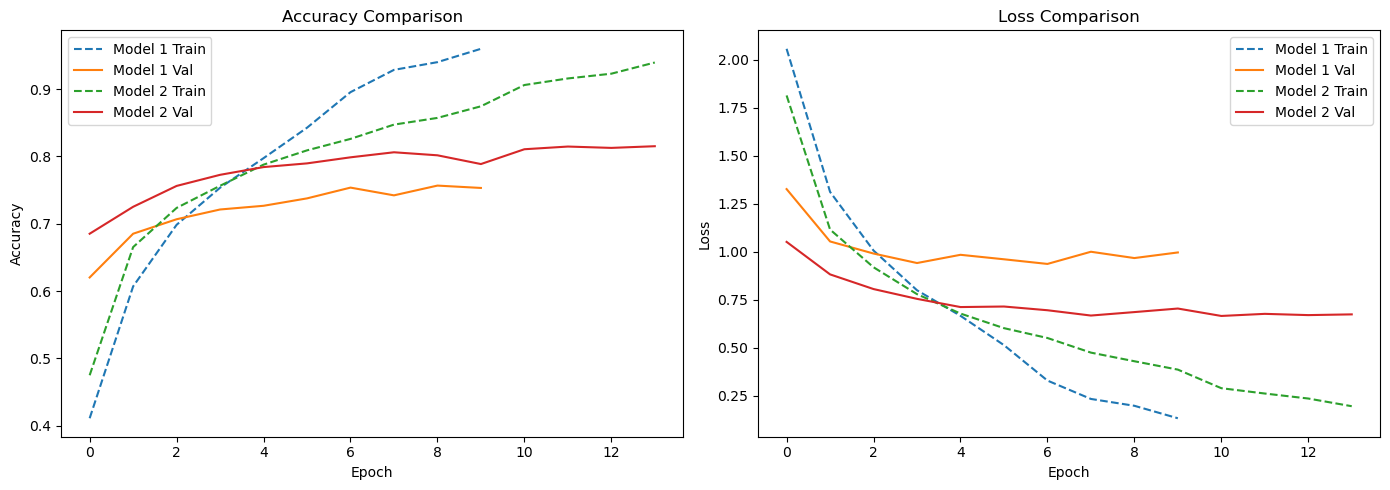

In [11]:
plot_history_comparison(
    [history_1, history_2],
    ["Model 1", "Model 2"]
)

Model 1

Model 1 achieved a high training accuracy, but its validation accuracy stayed much lower. The gap between training and validation performance shows that the model is overfitting. It learned the training data very well, but it did not generalize as effectively to unseen validation data. The loss curves also support this, since the training loss kept decreasing while the validation loss remained noticeably higher. Overall, Model 1 was too complex for this setup and was not the best choice for final use.

Model 2

Model 2 showed better validation performance than Model 1 and achieved the highest validation accuracy among the first two models. The gap between training and validation curves was smaller than in Model 1, which means overfitting was reduced. However, some difference between training and validation performance is still visible, so the model is not fully stable. In general, Model 2 was an improvement over Model 1 because it balanced learning and generalization better.

## Model 3 

In [8]:
callbacks_model_3 = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_model_3.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [9]:
model_3, base_model_3 = build_transfer_model(
    num_classes=NUM_CLASSES,
    fine_tune=True,
    unfreeze_top_layers=10,
    dropout_rate=0.6,
    dense_units=256,
    learning_rate=1e-5
)

history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_model_3
)

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0620 - loss: 3.7331
Epoch 1: val_loss improved from None to 2.62287, saving model to best_model_3.keras

Epoch 1: finished saving model to best_model_3.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.0948 - loss: 3.3820 - val_accuracy: 0.2869 - val_loss: 2.6229 - learning_rate: 1.0000e-05
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2049 - loss: 2.7519
Epoch 2: val_loss improved from 2.62287 to 2.02885, saving model to best_model_3.keras

Epoch 2: finished saving model to best_model_3.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 526s 2s/step - accuracy: 0.2437 - loss: 2.6185 - val_accuracy: 0.4343 - val_loss: 2.0289 - learning_rate: 1.0000e-05
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3478 - loss: 2.2669
Epoch 3: val_loss improved from 2.02885 to 1.70098, saving model to best_model_3.keras

Epoch 3: finished saving model to best_model_3.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 460s

In [ ]:
def plot_history(history, title="Model 3"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

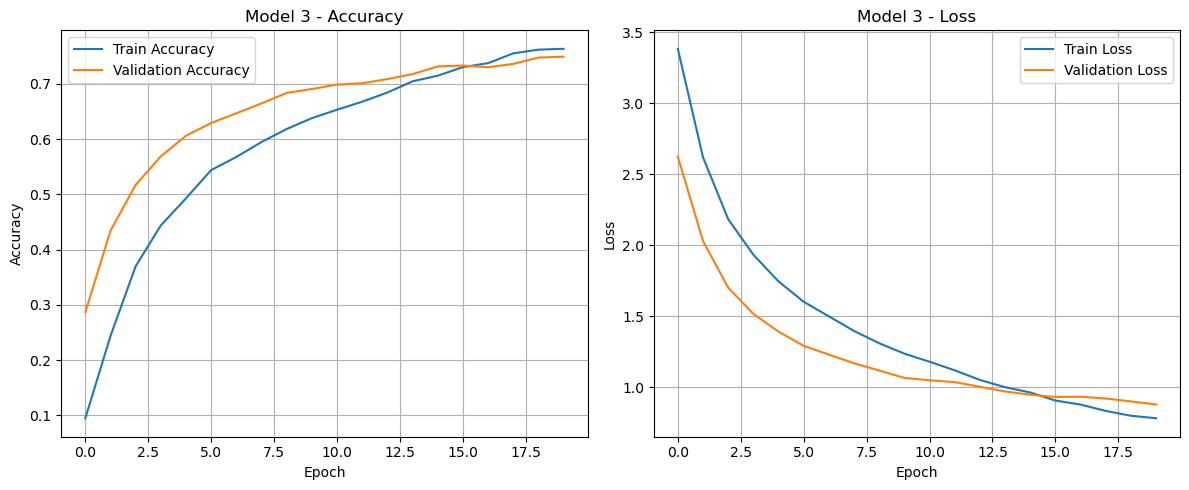

In [11]:
plot_history(history_3, "Model 3")

Model 3

Model 3 gave the most balanced results overall. The training and validation accuracy curves stay very close to each other during training, which suggests that the model generalized well and did not overfit strongly. The loss curves are also smooth and consistent, showing stable learning behavior. Even though its final validation accuracy is slightly lower than the strongest-performing models, Model 3 is the most reliable because it has the best balance between accuracy and generalization. For this reason, Model 3 can be considered the best overall model.

## Model 4

Since the model with fewer trainable layers showed better validation performance, the next experiment keeps the fine-tuning depth small and instead adjusts the dropout rate. This helps test whether stronger regularization can improve generalization without increasing model complexity.

In [23]:
callbacks_model_4 = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_model_4.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [24]:
model_4, base_model_4 = build_transfer_model(
    num_classes=NUM_CLASSES,
    fine_tune=True,
    unfreeze_top_layers=5,
    dropout_rate=0.4,
    dense_units=256,
    learning_rate=1e-5
)

history_4 = model_4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_model_4
)

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0740 - loss: 3.5451
Epoch 1: val_loss improved from None to 2.57420, saving model to best_model_4.keras

Epoch 1: finished saving model to best_model_4.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.1085 - loss: 3.2510 - val_accuracy: 0.2819 - val_loss: 2.5742 - learning_rate: 1.0000e-05
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2298 - loss: 2.6942
Epoch 2: val_loss improved from 2.57420 to 2.19377, saving model to best_model_4.keras

Epoch 2: finished saving model to best_model_4.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 542s 2s/step - accuracy: 0.2556 - loss: 2.6005 - val_accuracy: 0.3983 - val_loss: 2.1938 - learning_rate: 1.0000e-05
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3259 - loss: 2.3682
Epoch 3: val_loss improved from 2.19377 to 1.93867, saving model to best_model_4.keras

Epoch 3: finished saving model to best_model_4.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 521s

In [ ]:
def plot_history(history, title="Model 4"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

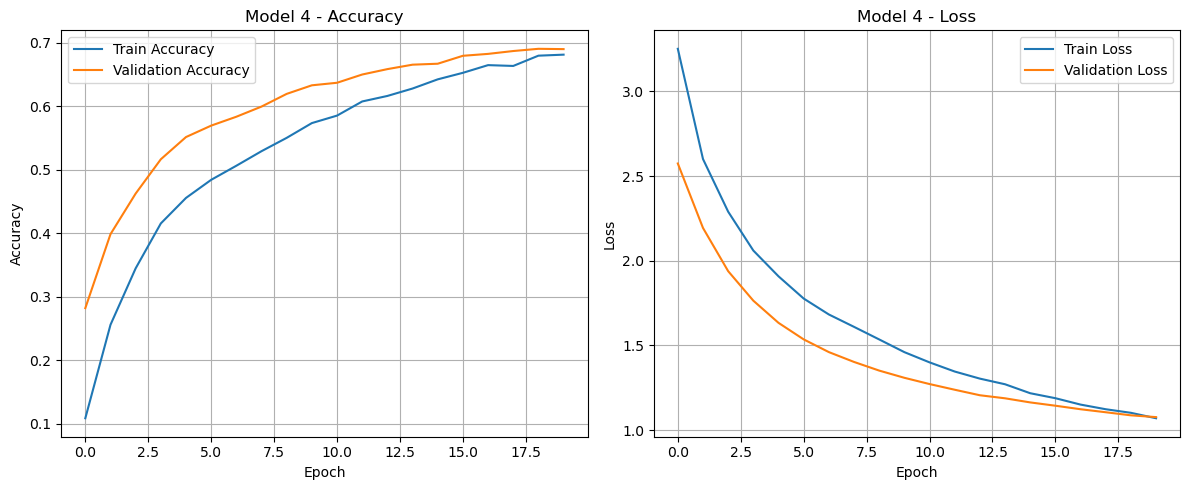

In [26]:
plot_history(history_4, "Model 4")

Model 4

Model 4 shows stable training behavior, and the validation accuracy is slightly higher than the training accuracy during most epochs. This is a good sign that the model is not overfitting. However, the final accuracy is lower than in Models 3 and 5, which means the model is likely underfitting. In other words, it is not powerful enough to capture all important patterns in the data. Model 4 is more regularized, but this came at the cost of lower overall performance.

## Model 5

In [27]:
callbacks_model_5 = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        mode="min",
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_model_5.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [28]:
model_5, base_model_5 = build_transfer_model(
    num_classes=NUM_CLASSES,
    fine_tune=True,
    unfreeze_top_layers=10,
    dropout_rate=0.5,
    dense_units=256,
    learning_rate=1e-5
)

history_5 = model_5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_model_5
)

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0825 - loss: 3.5715
Epoch 1: val_loss improved from None to 2.43273, saving model to best_model_5.keras

Epoch 1: finished saving model to best_model_5.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.1264 - loss: 3.2030 - val_accuracy: 0.3328 - val_loss: 2.4327 - learning_rate: 1.0000e-05
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2888 - loss: 2.5045
Epoch 2: val_loss improved from 2.43273 to 1.87340, saving model to best_model_5.keras

Epoch 2: finished saving model to best_model_5.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 539s 2s/step - accuracy: 0.3223 - loss: 2.3945 - val_accuracy: 0.4843 - val_loss: 1.8734 - learning_rate: 1.0000e-05
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4075 - loss: 2.0346
Epoch 3: val_loss improved from 1.87340 to 1.56770, saving model to best_model_5.keras

Epoch 3: finished saving model to best_model_5.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 544s

In [ ]:
def plot_history(history, title="Model 5"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

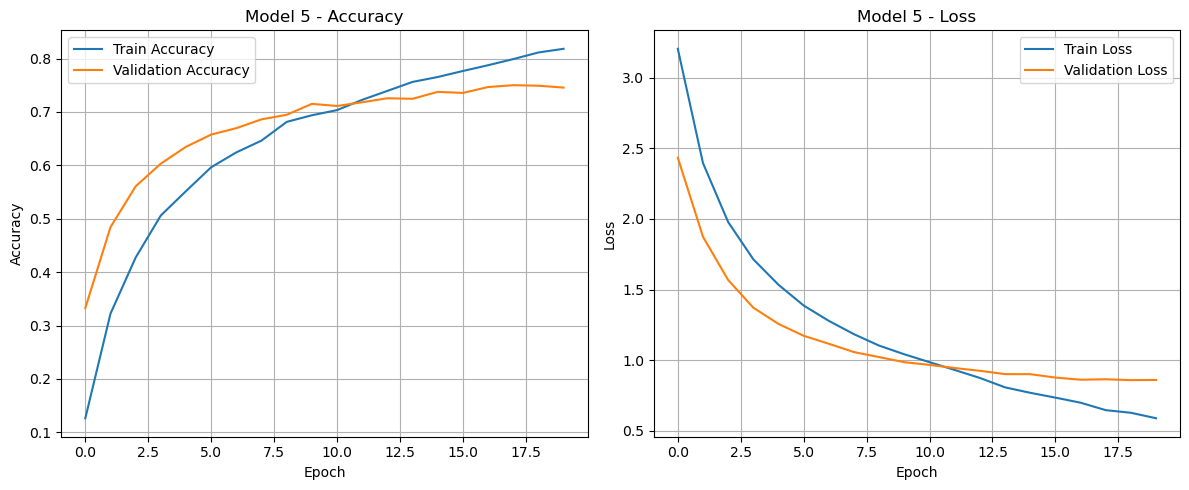

In [30]:
plot_history(history_5, "Model 5")

Model 5

Model 5 achieved the highest training accuracy among Models 3, 4, and 5, and it also reached strong validation accuracy. This shows that the model has good learning capacity. However, the gap between training and validation performance started to increase in later epochs, and the validation loss stopped improving as much as the training loss. This suggests that overfitting began to appear. Model 5 performed well, but it looks less stable than Model 3. Therefore, it can be seen as a strong model, but not the most reliable one for generalization.